## 7.18 분자 연산자의 기대값 계산

In [16]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector, partial_trace
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
import matplotlib.pyplot as plt
import koreanize_matplotlib

from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_qsphere,
    plot_state_city,
    plot_state_hinton,
)

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [17]:
# 단순 분자 해밀토니안을 파울리 연산자 합으로 정의
pauli_terms = {
    "II": -1.052373245772859,
    "IZ": 0.39793742484318045,
    "ZI": -0.39793742484318045,
    "ZZ": -0.01128010425623538,
    "XX": 0.18093119978423156,
}

In [18]:
# 해밀토니안의 SparsePauliOp 표현 생성
pauli_op_list = [(pauli_str, coef) for pauli_str, coef in pauli_terms.items()]
hamiltonian = SparsePauliOp.from_list(pauli_op_list)

In [19]:
# 분자 상태용 매개변수 양자회로(앤사츠) 정의
def create_ansatz(theta1, theta2):
    circuit = QuantumCircuit(2)
    circuit.rx(theta1, 0)
    circuit.ry(theta2, 1)
    circuit.cx(0, 1)
    return circuit

In [20]:
# 앤사츠 매개변수 초기화
theta1, theta2 = np.random.random(), np.random.random()
# 양자회로 생성
ansatz = create_ansatz(theta1, theta2)

양자 회로 (앤사츠):


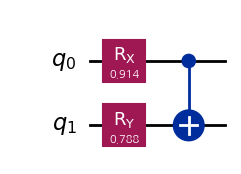

In [21]:
# 양자회로 시각화 (MPL 형식)
print("양자 회로 (앤사츠):")
ansatz.draw("mpl")
plt.show()

In [22]:
# 양자회로를 트랜스파일·시뮬레이션해 상태벡터 획득
simulated_circuit = transpile(ansatz)
state = Statevector.from_instruction(simulated_circuit)

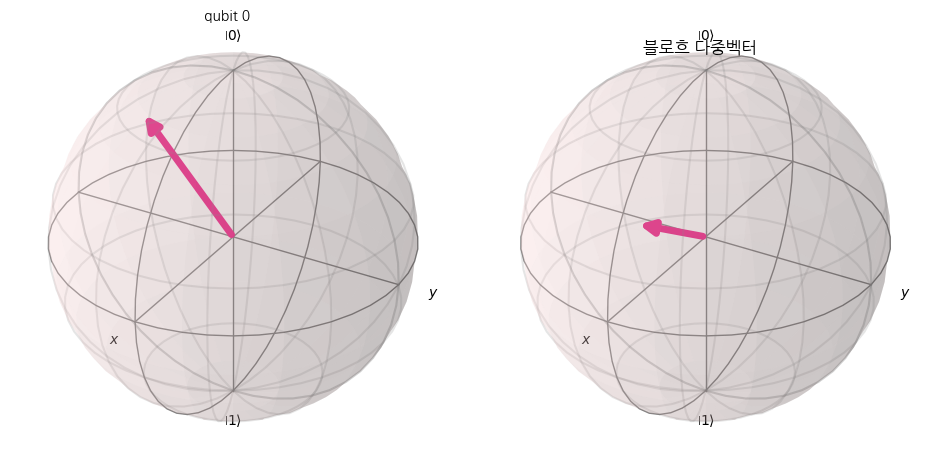

In [23]:
# 시각화: 블로흐 다중벡터
plot_bloch_multivector(state)
plt.title("블로흐 다중벡터")
plt.show()

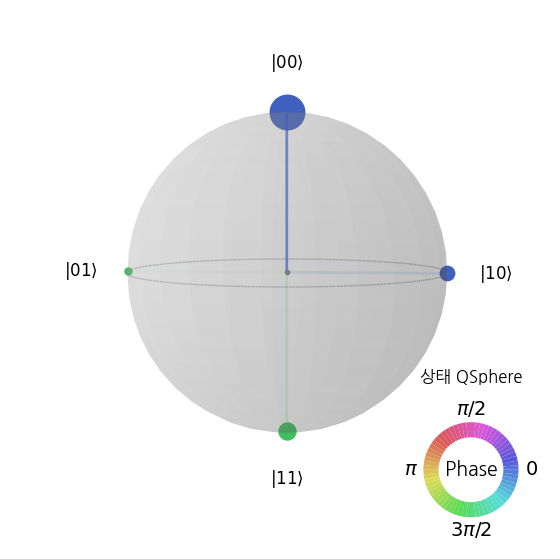

In [24]:
# 시각화: QSphere
plot_state_qsphere(state)
plt.title("상태 QSphere")
plt.show()

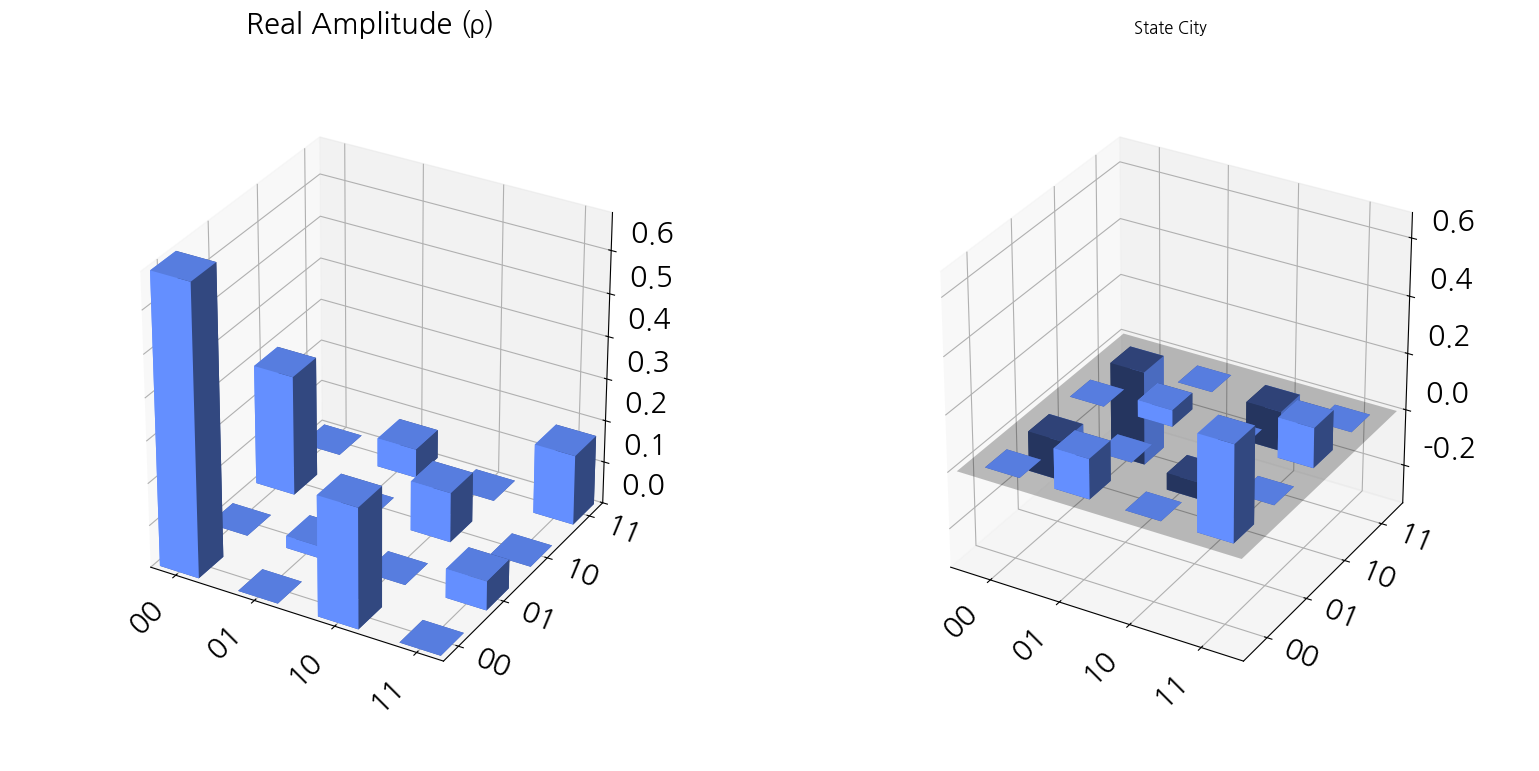

In [25]:
# 시각화: State City 플롯
plot_state_city(state)
plt.title("State City")
plt.show()

In [26]:
# # 시각화: 부분 대각합 플롯 (한 큐비트의 축소 밀도행렬)
# rho = partial_trace(state, [0])
# plot_state_hinton(rho)
# plt.title("부분 대각합 (큐비트 0)")
# plt.show()

In [27]:
# 기대값 계산을 위한 Estimator 인스턴스화
estimator = StatevectorEstimator()  # 호환성 수정: V2 추정기

In [28]:
# 해밀토니안의 기대값 계산
# 호환성 수정: V2 Estimator API — run([(회로, 관측량)]) → result()[0].data.evs
expectation_value = float(np.asarray(estimator.run([(ansatz, hamiltonian)]).result()[0].data.evs))
print(f"\n해밀토니안의 기대값: {expectation_value:.6f}")


해밀토니안의 기대값: -0.988744


In [29]:
# 시각화: 서로 다른 매개변수에 따른 기대값의 변화
theta1_values = np.linspace(0, 2 * np.pi, 50)
theta2_values = np.linspace(0, 2 * np.pi, 50)
expectation_values = []
for t1, t2 in zip(theta1_values, theta2_values):
    circuit = create_ansatz(t1, t2)
    # 호환성 수정: V2 Estimator API
    ev = float(np.asarray(estimator.run([(circuit, hamiltonian)]).result()[0].data.evs))
    expectation_values.append(ev)

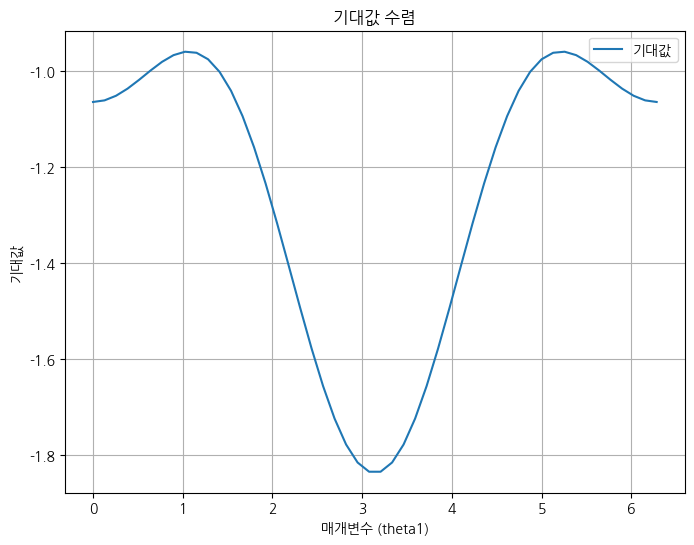

In [30]:
# 매개변수의 함수로 기대값 플롯
plt.figure(figsize=(8, 6))
plt.plot(theta1_values, expectation_values, label="기대값")
plt.xlabel("매개변수 (theta1)")
plt.ylabel("기대값")
plt.title("기대값 수렴")
plt.legend()
plt.grid()
plt.show()